# HEST coverage95 statistical baselines

This notebook summarizes the first formal benchmark baselines for the high-confidence HEST human Visium coverage95 target. These are not external deep-learning methods; they are lower-bound controls that quantify how much count-scale performance can be explained by average gene rates plus size-factor variation.

## Baseline definitions

- `global_mean_rate`: train-set mean rate for each gene, repeated at every test spot.
- `global_sf_only_count_pred_sf`: train-set mean rate multiplied by the fixed H&E-derived SF predictor.
- `global_sf_only_count_oracle_sf`: train-set mean rate multiplied by true SF; this is an oracle SF-only control.
- `organ_sf_only_count_pred_sf`: train-set organ-specific mean rate multiplied by the H&E-derived SF predictor.
- `organ_sf_only_count_oracle_sf`: organ-specific mean rate multiplied by true SF; this is an organ-aware oracle SF-only control.

The external-model benchmark harness remains separate. These baselines are meant to anchor interpretation before adapting HisToGene, HiST, iStar, mclSTExp, sCellST, and THItoGene.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

CWD = Path.cwd()
ROOT = CWD if (CWD / "configs").exists() else CWD.parent
BASE = ROOT / "results" / "hest1k_human_visium_expression"
STAT = BASE / "statistical_baselines"
DIAG = BASE / "coverage95_diagnostics"

required = [
    STAT / "summary.csv",
    STAT / "run_summary.json",
    DIAG / "run_summary.json",
]
missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
assert not missing, missing

stat_summary = pd.read_csv(STAT / "summary.csv")
stat_run = json.loads((STAT / "run_summary.json").read_text(encoding="utf-8"))
diag_run = json.loads((DIAG / "run_summary.json").read_text(encoding="utf-8"))

histoomnist_row = {
    "method": "HistoOmniST_count_pred_sf",
    "prediction_kind": "count",
    **diag_run["expression_overall"]["count_pred_sf"],
}
compare = pd.concat([stat_summary, pd.DataFrame([histoomnist_row])], ignore_index=True)

display(Markdown(f"Train slides: **{stat_run['n_train_slides']}**; test slides: **{stat_run['n_test_slides']}**; genes: **{stat_run['n_genes']}**"))
compare.round(4)

Train slides: **163**; test slides: **48**; genes: **16942**

,method,prediction_kind,mean_gene_pearson,median_gene_pearson,valid_genes
0,global_mean_rate,rate,0.0000,0.0000,2962
1,global_sf_only_count_pred_sf,count,0.1413,0.1443,16942
2,global_sf_only_count_oracle_sf,count,0.2029,0.2110,16942
3,organ_sf_only_count_pred_sf,count,0.2494,0.2628,16942
4,organ_sf_only_count_oracle_sf,count,0.3136,0.3323,16942
5,HistoOmniST_count_pred_sf,count,0.3529,0.3780,16942


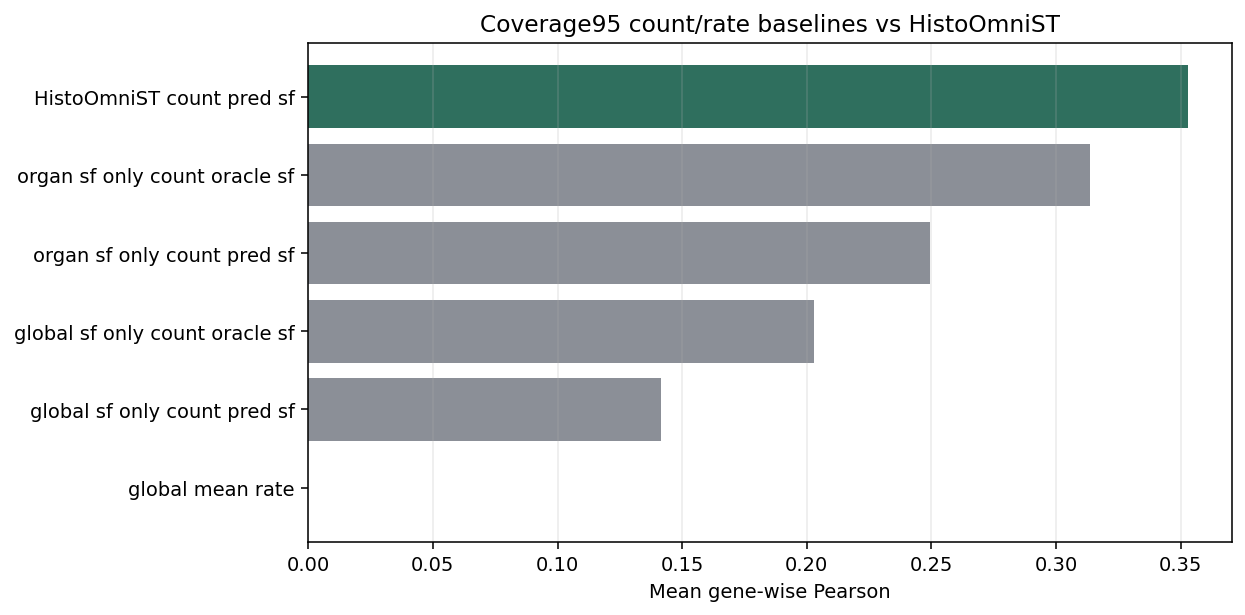

In [2]:
plot_df = compare.copy()
plot_df["label"] = plot_df["method"].str.replace("_", " ")
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=140)
ax.barh(plot_df["label"], plot_df["mean_gene_pearson"], color=["#8b8f97"] * (len(plot_df) - 1) + ["#2f6f5e"])
ax.set_xlabel("Mean gene-wise Pearson")
ax.set_title("Coverage95 count/rate baselines vs HistoOmniST")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## Organ-level localization

The table below uses flattened spot-gene metrics. It is useful for diagnosing domain behavior, but headline benchmark reporting should still use gene-wise Pearson.

,organ,pred_sf_pearson,pred_sf_mae,pred_sf_rmse,oracle_sf_pearson,oracle_sf_mae,oracle_sf_rmse
4,Heart,0.5821,0.2622,2.6978,0.6394,0.2473,2.5731
3,Eye,0.4261,0.3617,3.3263,0.4551,0.3527,3.2906
1,Brain,0.4151,0.3336,1.4290,0.4914,0.3211,1.3692
2,Breast,0.4040,1.2802,8.5749,0.4211,1.2469,8.6263
5,Skin,0.3679,0.3232,7.2114,0.4356,0.2991,6.9837
0,Bowel,0.2236,0.8849,7.8799,0.2567,0.8079,7.9258


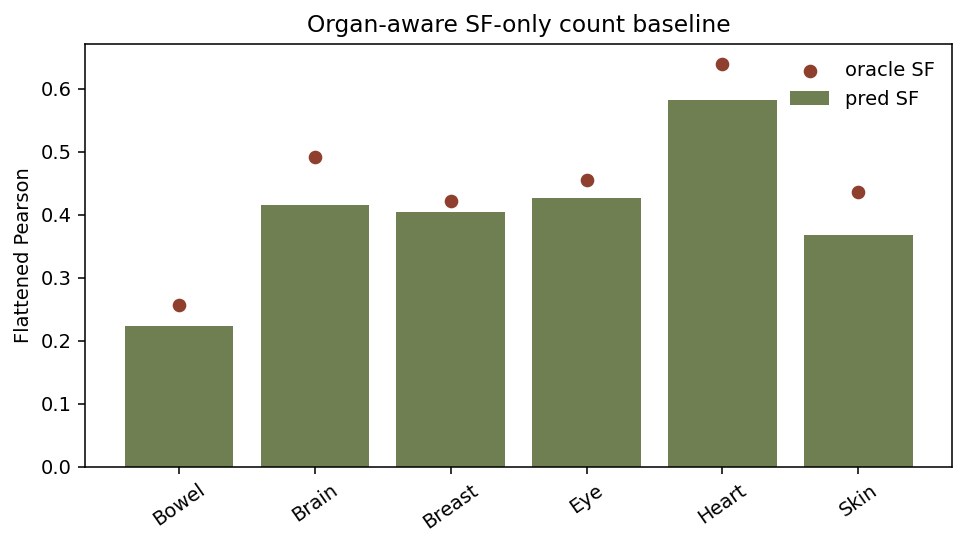

In [3]:
organ_pred = pd.read_csv(STAT / "organ_sf_only_count_pred_sf" / "per_organ_metrics.csv")
organ_oracle = pd.read_csv(STAT / "organ_sf_only_count_oracle_sf" / "per_organ_metrics.csv")
organ_compare = organ_pred[["organ", "pearson", "mae", "rmse"]].rename(columns={"pearson": "pred_sf_pearson", "mae": "pred_sf_mae", "rmse": "pred_sf_rmse"})
organ_compare = organ_compare.merge(
    organ_oracle[["organ", "pearson", "mae", "rmse"]].rename(columns={"pearson": "oracle_sf_pearson", "mae": "oracle_sf_mae", "rmse": "oracle_sf_rmse"}),
    on="organ",
    how="left",
)
display(organ_compare.sort_values("pred_sf_pearson", ascending=False).round(4))

fig, ax = plt.subplots(figsize=(7, 4), dpi=140)
ax.bar(organ_compare["organ"], organ_compare["pred_sf_pearson"], color="#6f7f52", label="pred SF")
ax.scatter(organ_compare["organ"], organ_compare["oracle_sf_pearson"], color="#8f3f2d", label="oracle SF", zorder=3)
ax.set_ylabel("Flattened Pearson")
ax.set_title("Organ-aware SF-only count baseline")
ax.tick_params(axis="x", rotation=35)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Interpretation checkpoint

The H&E-derived SF-only count baseline reaches mean gene-wise Pearson 0.141 with global rates and 0.249 with organ-specific rates. The full HistoOmniST coverage95 `count_pred_sf` result is 0.353. The oracle SF-only controls reach 0.203 and 0.314, which shows that SF and organ composition explain a meaningful part of count-scale signal, but do not close the gap to the expression model.

This supports the next benchmark step: adapt external ST-prediction methods under the same split, target genes, and evaluator, then compare them against both HistoOmniST and these SF-only controls.